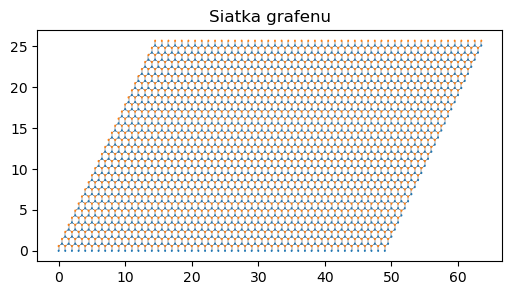

In [4]:
# Biblioteki
import kwant
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Siatka - grafen
lat = kwant.lattice.honeycomb(norbs=1)
a, b = lat.sublattices
sys = kwant.Builder()

# Rozmiar
L, W = 50, 30

# Prostokątna siatka
# def rectangle(pos):
#     x, y = pos
#     return 0 <= x < L and 0 <= y < W
#sys[lat.shape(rectangle, (0, 0))] = 0

# Wypełnianie
all_sites = [s(i, j) for s in [a, b] for i in range(L) for j in range(W)]
sys[all_sites] = 0 # a nie mu = 0.1
sys[lat.neighbors()] = -1

sys[all_sites] = 0
sys[lat.neighbors()] = -1 # bez pola B -1 * t, gdzie t = 2.7 eV

fig, ax = plt.subplots(figsize=(6, 3))
kwant.plot(sys, ax=ax)
ax.set_title("Siatka grafenu")
plt.show()

In [7]:
# Kontakty
sym = kwant.TranslationalSymmetry(lat.vec((1, 0)))
lead = kwant.Builder(sym)

# Wypełnienie pionowej komórki
lead_sites = [s(0, j) for s in [a, b] for j in range(W)]
lead[lead_sites] = 0
lead[lat.neighbors()] = -1

# Podpięcie
sys.attach_lead(lead)
sys.attach_lead(lead.reversed())

# Finalizacja
fsys = sys.finalized()

@interact(e=(0.01, 1.2, 0.05))
def plot(e=0.5):
    wf = kwant.wave_function(fsys, energy=e)
    psi = wf(0)
    if len(psi) == 0: return print("Brak modów przewodzących")
    psi_total = np.sum(np.abs(psi)**2, axis=0)

    coords = np.array([s.pos for s in fsys.sites])
    
    plt.figure(figsize=(10, 5))
    sc = plt.scatter(coords[:,0], coords[:,1], c=psi_total, cmap='viridis', s=40, edgecolors='none')
    plt.colorbar(sc, label="|ψ|²")
    plt.title(f"Gęstość prawdopodobieństwa (E = {e:.2f})")
    plt.axis('equal')
    plt.show()

# # 3.Rysowanie
# fig, ax = plt.subplots(figsize=(8, 4))
# kwant.plot(fsys, ax=ax)
# ax.set_title("Siatka grafenu + kontakty")
# plt.show()

interactive(children=(FloatSlider(value=0.5, description='e', max=1.2, min=0.01, step=0.05), Output()), _dom_c…

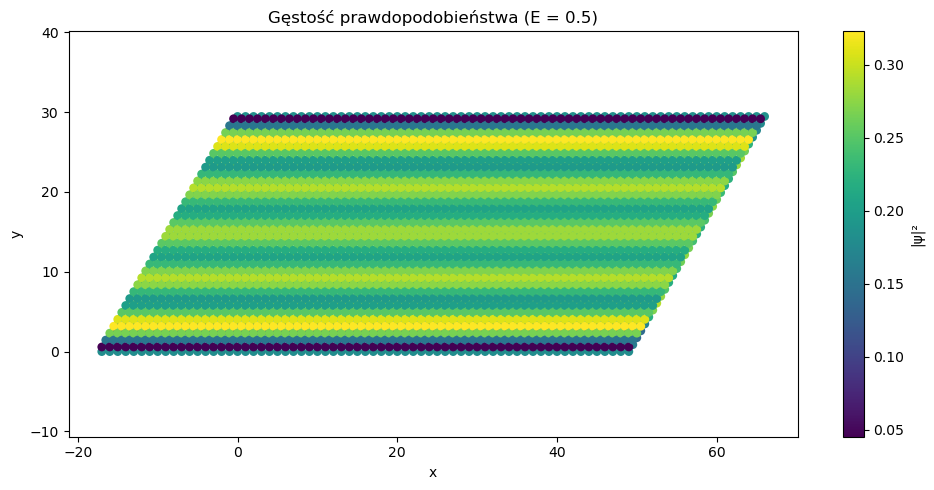

In [109]:
# --- 4. Poprawiona wizualizacja (Scatter zamiast Tripcolor) ---

def PSI_par(fsys_par, energy_par, title):
    # 1. Obliczenie funkcji falowej
    wf = kwant.wave_function(fsys_par, energy=energy_par)
    psi_par = wf(0) 
    
    # 2. Bezpieczne sumowanie gęstości prawdopodobieństwa
    # np.sum z axis=0 zapewnia, że dostaniemy wektor o długości równej liczbie atomów
    psi_total = np.sum(np.abs(psi_par)**2, axis=0)

    # 3. Pobranie współrzędnych
    coords = np.array([site.pos for site in fsys_par.sites])
    x_coords = coords[:, 0]
    y_coords = coords[:, 1]

    # 4. Rysowanie punktowe (Scatter) - brak artefaktów "płatków śniegu"
    plt.figure(figsize=(10, 5))
    # s=40 dobiera rozmiar punktu tak, by "zakryć" dziury wizualnie
    sc = plt.scatter(x_coords, y_coords, c=psi_total, cmap='viridis', s=40, edgecolors='none')
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.colorbar(sc, label="|ψ|²")
    plt.axis('equal') # Zachowuje proporcje siatki
    plt.tight_layout()
    plt.show()

# Wywołanie
PSI_par(fsys, energy_par=0.5, title="Gęstość prawdopodobieństwa (E = 0.5)")

In [89]:
# --- 3. DODANIE POLA MAGNETYCZNEGO ---

def hopping_phi(site1, site2, phi):
    # Faza Peierlsa: t * exp(i * faza)
    # phi to strumień magnetyczny na oczko sieci
    x1, y1 = site1.pos
    x2, y2 = site2.pos
    return -1 * np.exp(-1j * phi * (x1 + x2) * (y1 - y2))

# Parametr pola magnetycznego (strumień phi)
# Zacznij od małej wartości, np. 0.05, żeby zobaczyć efekt
phi_value = 0.05

# Podmieniamy stały przeskok (-1) na funkcję z fazą
sys[lat.neighbors()] = lambda s1, s2: hopping_phi(s1, s2, phi_value)

# UWAGA: Musisz też zaktualizować przeskoki w elektrodach, 
# aby były spójne z systemem centralnym!
lead[lat.neighbors()] = lambda s1, s2: hopping_phi(s1, s2, phi_value)

# Teraz finalizujemy (po dodaniu pola B)
fsys = sys.finalized()

In [103]:
from ipywidgets import interact, FloatSlider

# --- 4. Interaktywna wizualizacja z suwakiem ---

def interactive_psi(energy):
    # 1. Obliczenie funkcji falowej
    wf = kwant.wave_function(fsys, energy=energy)
    psi_par = wf(0) 

    # 2. Sumowanie gęstości prawdopodobieństwa
    psi_total = np.sum(np.abs(psi_par)**2, axis=0)

    # 3. Pobranie współrzędnych
    coords = np.array([site.pos for site in fsys.sites])
    x_coords, y_coords = coords[:, 0], coords[:, 1]

    # 4. Rysowanie
    plt.figure(figsize=(10, 5))
    sc = plt.scatter(x_coords, y_coords, c=psi_total, cmap='viridis', s=45, edgecolors='none')
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Gęstość prawdopodobieństwa (E = {energy:.3f})")
    plt.colorbar(sc, label="|ψ|²")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# Definicja suwaka: start, stop, krok
energy_slider = FloatSlider(min=0.01, max=1.5, step=0.05, value=0.5, description='Energia:')

interact(interactive_psi, energy=energy_slider);

interactive(children=(FloatSlider(value=0.5, description='Energia:', max=1.5, min=0.01, step=0.05), Output()),…